<a href="https://colab.research.google.com/github/Tshiamo-SE-DS/PyTorch/blob/main/Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Tshiamo's FIT
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:06<00:00, 106MB/s] 


In [2]:
import torch #This is the main pytorch library
from torch import nn #The layers and Loss functions
from torch.optim import Adam #Optimizer
from torchvision.transforms import transforms#For pre-processing the images
from torch.utils.data import Dataset, DataLoader #To create custom datasets, and to loop through the batches that divide our dataset to batches
from sklearn.preprocessing import LabelEncoder# To convert our data outputs from strings to integers(integer encoded). instead of having cat, dog or wildlife, we will have 0, 1, 2.
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu" #PyTorch does not automatically detect the GPU, you have to tell it!
print("Device available: ", device)

Device available:  cuda


In [3]:
 #first of all we need to real all the data in animal-faces. We split the dataset by our selves. the data is split into train, validation and testing.
 #The code that follows will navigate a nested directory structure with subdirectories holding photos, each of which represents a distinct label (category). It creates a list of these images' file paths together with the labels that go with them. After that, it generates a pandas DataFrame with this data, which is helpful for additional data processing. Remember that after reading all of the data, it will be divided once more for testing, validation, and training.

image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):#looping through the first directory which has the train and validation images.
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):#looping through the first directory which has the labels folders.
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):#looping through the images of this label
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")#put this image path in the list to read it later.
      labels.append(label)#put label in the list

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])

print(data_df["labels"].unique())
data_df.head()

['dog' 'cat' 'wild']


,image_path,labels
0,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
1,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
2,/content/animal-faces/afhq/val/dog/flickr_dog_...,dog
3,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
4,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog


In [4]:
#Here we are splitting our dataset into 3 data frames(Training, Validation, Testing). Since we will be reading the image paths from the dataframe, We will split the dataframe directlty and then read the images For simplicity we will be using the sampling function, rather than the train test split.
#Since we will be reading the image paths from the dataframe, We will split the dataframe directlty and then read the images, by getting the random sample of 70% from our data.
#we will create a new variable of test dataset which we will drop from it the 70% of the train which means that it will be 30% of the data which is the rest of the data
#Then we will do the same between testing to create validation which will be 50% of the data which means the final split we have is Training: 70%, Validation: 15%, Testing: 15%.
train = data_df.sample(frac = 0.7)
test = data_df.drop(train.index)

val = test.sample(frac = 0.5)
test = test.drop(val.index)

print(train.shape)
print(val.shape)
print(test.shape)

(11291, 2)
(2420, 2)
(2419, 2)


In [5]:
#Here we are declaring our label encoder frist, then we have to fit it in our data we will have the transform function.
label_encoder = LabelEncoder() #enode the string classes to numeric
label_encoder.fit(data_df["labels"])


#transform, makes all the images to have the same properties(size/data type)
transform = transforms.Compose([
    transforms.Resize((128,128)), # one size for all images
    transforms.ToTensor(), #convert images to PyTorch tensors
    transforms.ConvertImageDtype(torch.float)#values are in floating point numbers
])#transform all images into one clear format/same properties

In [6]:
#Here we are creating a custom dataset. The class inherits from the main Dataset class from PyTorch. then we overwrite some of the existing functions in that class.
#First we define our class that will be taking the main Dataset class with the concept of inheritance.
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):#we are declaring and our dataframe which will have image_path and the labels
    self.dataframe = dataframe
    self.transform = transform#Then we are creating our own image preprocessing object which is transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)#We are defining the objects inside this class. We are creating a torch.tensor, which is from the data frame of labels. Using the label enoder to transform them into integers(0,1,2) instead of strings(cat, wild, dog).

  def __len__(self):# this is a built-in function so we have to use the same syntax
    return self.dataframe.shape[0]

  def __getitem__(self, idx): #we are reading each image, applying the preprocessing and returning it in the __getitem__ to read this specific image with its corresponding encoded label by their index and returns them.
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(device)

    return image, label


In [7]:
#here we are creating the 3 dataset for Training data, Validation data and Testing data.
train_dataset = CustomImageDataset(dataframe = train, transform = transform)
val_dataset = CustomImageDataset(dataframe = val, transform = transform)
test_dataset = CustomImageDataset(dataframe = test, transform = transform)

In [8]:
train_dataset.__len__()

11291

In [9]:
train_dataset.__getitem__(2)

(tensor([[[0.0784, 0.0784, 0.0784,  ..., 0.9961, 0.9490, 0.8078],
          [0.0745, 0.0745, 0.0745,  ..., 0.9961, 0.9686, 0.8510],
          [0.0706, 0.0706, 0.0706,  ..., 0.9922, 0.9804, 0.9255],
          ...,
          [0.0941, 0.0353, 0.0392,  ..., 0.3490, 0.2314, 0.2235],
          [0.0392, 0.0392, 0.0431,  ..., 0.3725, 0.2667, 0.2353],
          [0.0510, 0.0471, 0.0431,  ..., 0.3490, 0.2549, 0.2431]],
 
         [[0.0275, 0.0275, 0.0275,  ..., 0.8588, 0.7765, 0.6196],
          [0.0314, 0.0314, 0.0314,  ..., 0.8706, 0.8118, 0.6667],
          [0.0353, 0.0353, 0.0353,  ..., 0.8863, 0.8431, 0.7412],
          ...,
          [0.1098, 0.0471, 0.0353,  ..., 0.3020, 0.1882, 0.1882],
          [0.0392, 0.0392, 0.0392,  ..., 0.3137, 0.2157, 0.1882],
          [0.0392, 0.0392, 0.0392,  ..., 0.2667, 0.1804, 0.1725]],
 
         [[0.0549, 0.0549, 0.0549,  ..., 0.6392, 0.5765, 0.4314],
          [0.0549, 0.0549, 0.0549,  ..., 0.6471, 0.6078, 0.4784],
          [0.0549, 0.0549, 0.0549,  ...,

In [10]:
label_encoder.inverse_transform([2])

array(['wild'], dtype=object)

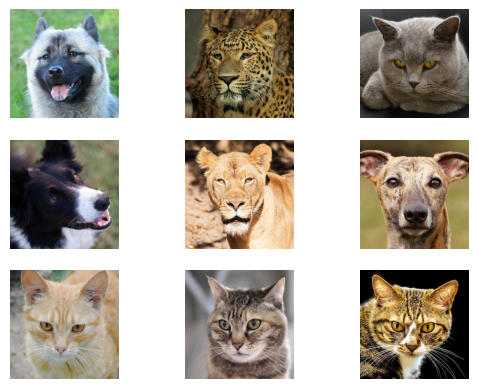

In [11]:
#Here we are visualizing the random images from the data
n_rows = 3 #displaying the in a grid form, a matrix of 3x3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):#loop through each row
  for col in range(n_cols):#looping through each column
    image = Image.open(data_df.sample(n = 1)["image_path"].iloc[0]).convert("RGB")#read image
    axarr[row, col].imshow(image)
    axarr[row, col].axis("off")

plt.show()

In [12]:
#Here we are setting the training hyperparameters
LR = 1e-4 #Learning Rate
BATCH_SIZE = 16
EPOCHS = 10

In [13]:
#Here we are building the data loaders for all dataset. Dataloader allows you to loop through the batches easily during the training. When you create a dataloader. You define the batch size and enable the shuffle to randomize the data and then you can loop through it in each epoch to train normally.
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = True)

In [14]:
#Here we are going to build the model, starting with the model class that inherits from the nn Module
class Net(nn.Module):
  def __init__(self):#Constructor
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size = 3, padding = 1)# 1st convolution layer is going to take 3 channels because its an RGB image, it outputs 32(optional) channels, with the kernal size of 3
    self.conv2 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1)# 2nd convolution layer
    self.conv3 = nn.Conv2d(64, 128, kernel_size = 3, padding = 1)# 3rd convolution layer

    self.pooling = nn.MaxPool2d(2,2)#Pooling Layer: using the same layer each conv2d

    self.relu = nn.ReLU()#Activation Function

    self.flatten = nn.Flatten()#Flattening Layer: flatten and vectorize the output feature maps that sums from the final convolution layeer.
    self.linear = nn.Linear((128*16*16), 128)# Traditional Dense(linear)

    self.output = nn.Linear(128, len(data_df['labels'].unique()))#Output linear layer

  def forward(self, x):#Forward Function
    x = self.conv1(x)#Output(32, 128, 128)
    x = self.pooling(x)#Output(32, 64, 64)
    x = self.relu(x)

    x = self.conv2(x)#Output(64, 64, 64)
    x = self.pooling(x)#Output(32, 64, 64)
    x = self.relu(x)

    x = self.conv3(x)#Output(128, 32, 32)
    x = self.pooling(x)#Output(128, 16, 16)
    x = self.relu(x)

    x = self.flatten(x)
    x = self.linear(x)
    x = self.output(x)
    return x

model = Net().to(device) # Create an instance of the model and move it to the GPU device.

In [15]:
#Model Summary
from torchsummary import summary
summary(model, input_size = (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [16]:
#Before we start with the training, we must define the loss and optimizer.
criterion = nn.CrossEntropyLoss()#Loss Function. we are using cross entropy because its a multiclass, if it was binary, we were going to use BCE
optimizer = Adam(model.parameters(), lr = LR)#Optimizer. We are optimizing the parameters(weights) of this neural netwrok


In [17]:
#We start by initializing the for loop with the specified number of epochs which we defined before. But before that we define 4 lists and inside the loop we define another 4 variables.
#These lists are to score the epochs. the loss after each epoch of the training, validation and accuracy, so that we can visualize them at the end, to know if there was any overfitting insode the model
total_loss_train_plot = []#We append the losses of the training accuracy to visualize them at the end.
total_loss_validation_plot = []#We append the losses of the training to visualize them at the end.
total_acc_train_plot = []#We append the losses of the validation accuracy to visualize them at the end.
total_acc_validation_plot = []#We append the losses of the validation to visualize them at the end.

for epoch in range(EPOCHS):#we use the enumerate functionality to loop through data and indices at the same time.
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:#In the second loop, we start by getting our data from the data loader, then we move the inputs and labels to the cuda device
    optimizer.zero_grad()#We allow the model to make a prediction or what is called forward propagation, then we get the output of the model and compare it with our original output using the loss criteration.

    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()#We add the loss amount to total_loss_train. Additionally, we get the accuracy by comparing the correct batch with the predicted batch and we add it to the total_acc_train

    train_loss.backward()# the batch_loss.backward() which makes the backpropagation and we use the optimizer to do a step on the weights.

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()

    total_acc_train += train_acc
    optimizer.step()

  """
  After that we exit the batch loop (train dataloader loop) and we start with the validation. Don't forget that we are still in the same epoch.
  In side that we start by with torch.no_grad() so that we freeze the weights, which means that we need the model to do predicitons without being trained.
  We just need to see the validation preformance. Then we do the same steps which are predicting and calculating loss and accuracy and storing these values.
  """
  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))

  total_acc_train_plot.append(round((total_acc_train/train_dataset.__len__()) * 100, 4))
  total_acc_validation_plot.append(round((total_acc_val/val_dataset.__len__()) * 100, 4))

  print(f'''Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy {round((total_acc_train/train_dataset.__len__()) * 100, 4)}
              Validation Loss: {round(total_loss_val/1000, 4)} Validation Accuracy {round((total_acc_val/val_dataset.__len__()) * 100, 4)}
        ''')

Epoch 1/10, Train Loss: 0.3303 Train Accuracy 80.7812
              Validation Loss: 0.046 Validation Accuracy 89.0496
        
Epoch 2/10, Train Loss: 0.1522 Train Accuracy 91.8696
              Validation Loss: 0.0278 Validation Accuracy 93.7603
        
Epoch 3/10, Train Loss: 0.0958 Train Accuracy 94.8986
              Validation Loss: 0.0224 Validation Accuracy 95.0
        
Epoch 4/10, Train Loss: 0.0699 Train Accuracy 96.4042
              Validation Loss: 0.0209 Validation Accuracy 95.2066
        
Epoch 5/10, Train Loss: 0.0525 Train Accuracy 97.3342
              Validation Loss: 0.0191 Validation Accuracy 95.4545
        
Epoch 6/10, Train Loss: 0.0377 Train Accuracy 98.1844
              Validation Loss: 0.0183 Validation Accuracy 96.1157
        
Epoch 7/10, Train Loss: 0.0281 Train Accuracy 98.7158
              Validation Loss: 0.0286 Validation Accuracy 94.0909
        
Epoch 8/10, Train Loss: 0.0234 Train Accuracy 98.8664
              Validation Loss: 0.0206 Validatio

In [23]:
#Testing
'''we are telling PyTorch that we don't want to train the model we will be using it only for testing.
Then we will declare initial loss and accuracy as zeros, we will start by looping through the testing dataloader like we did before during training
'''
with torch.no_grad():# We are not going to change the model weights.
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:#Its the same way we do the validation,  but was in the loop
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is: {round(total_loss_test/100, 4)}")

Accuracy Score is: 95.8661 and Loss is: 0.2249


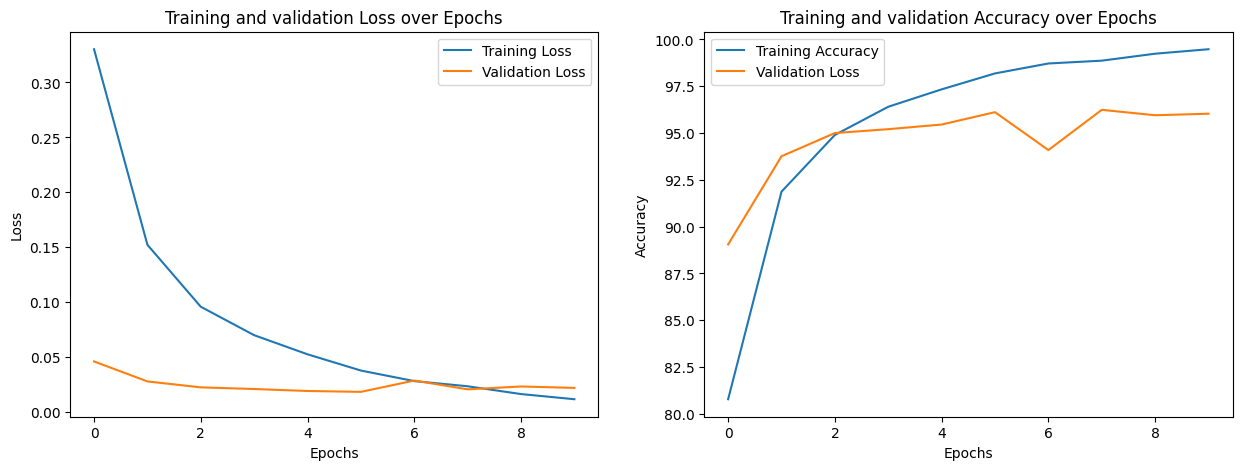

In [25]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))
axs[0].plot(total_loss_train_plot, label = "Training Loss")
axs[0].plot(total_loss_validation_plot, label = "Validation Loss")
axs[0].set_title("Training and validation Loss over Epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = "Training Accuracy")
axs[1].plot(total_acc_validation_plot, label = "Validation Loss")
axs[1].set_title("Training and validation Accuracy over Epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].legend()

plt.show()

In [ ]:
#Inference
